# 02 — Expense Trends

**Purpose:** Load monthly category aggregates, fit OLS linear trends per category,
detect seasonality, flag consecutive MoM rises, and inspect the results.
Save the full trend-annotated DataFrame to `data/interim/expense_trends.parquet`.

**Inputs:** `data/interim/monthly_aggregates.parquet`  
**Outputs:** `data/interim/expense_trends.parquet`

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from IPython.display import display

from src.utils.logging_config import setup_notebook_logging
from src.analysis.expense_trends import compute_expense_trends
from src.storage.local_writer import LocalWriter

logger = setup_notebook_logging()
writer = LocalWriter(project_root="..")


## Step 1 — Load monthly aggregates

In [2]:
# ── Load monthly aggregates ───────────────────────────────────────────────────
df_monthly = writer.load_interim("monthly_aggregates")
print(f"Loaded {df_monthly.shape[0]} rows × {df_monthly.shape[1]} columns")
print(f"Memory: {df_monthly.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Date range: {df_monthly['year_month'].min()} → {df_monthly['year_month'].max()}")
print(f"Categories: {df_monthly['category'].nunique()}")

2026-03-30 13:06:10 | src.storage.local_writer       | INFO     | Loaded 1639 rows from C:\Users\mkkom\MMEXtend\data\interim\monthly_aggregates.parquet


Loaded 1639 rows × 5 columns
Memory: 0.1 MB
Date range: 2017-09 → 2026-03
Categories: 31


## Step 2 — Compute expense trends

Runs OLS trend per category, seasonality CV check, and MoM consecutive-rise detection.
This may take a few seconds.

**Assumptions (OLS):**
1. Spend is approximately linear over time (no structural breaks)
2. Residuals are approximately normally distributed
3. No extreme outliers dominating the fit
4. Monthly observations are approximately independent

In [3]:
df_trends = compute_expense_trends(df_monthly)
print(f"Trends DataFrame: {df_trends.shape[0]} rows × {df_trends.shape[1]} columns")

2026-03-30 13:06:10 | src.analysis.expense_trends    | INFO     | Expense trends: 31 categories | 2 rising | 1 seasonal


Trends DataFrame: 1639 rows × 18 columns


## Step 3 — Trend summary table

Key questions:
1. Which categories are flagged as **rising**?
2. Are R² values high enough? (> 0.3 = informative, > 0.6 = strong)
3. Any categories flagged as **highly seasonal**?

In [4]:
# One row per category — deduplicate to get summary stats
trend_summary = (
    df_trends.drop_duplicates("category")
    .set_index("category")[[
        "trend_class", "trend_slope", "trend_r2", "trend_pvalue",
        "trend_n_months", "trend_ci_lower", "trend_ci_upper",
        "is_seasonal", "seasonality_cv", "has_consecutive_rise",
        "n_rise_runs", "share_pct",
    ]]
    .sort_values("share_pct", ascending=False)
)

display(
    trend_summary[["trend_class", "trend_slope", "trend_r2", "trend_pvalue",
                   "trend_n_months", "is_seasonal", "has_consecutive_rise",
                   "n_rise_runs", "share_pct"]]
    .style
    .background_gradient(subset=["share_pct"], cmap="Reds")
    .background_gradient(subset=["trend_r2"], cmap="Blues")
    .format({
        "trend_slope": "{:.2f}",
        "trend_r2": "{:.3f}",
        "trend_pvalue": "{:.4f}",
        "share_pct": "{:.1f}%",
    })
)

,trend_class,trend_slope,trend_r2,trend_pvalue,trend_n_months,is_seasonal,has_consecutive_rise,n_rise_runs,share_pct
category,,,,,,,,,
Income,rising,427.82,0.792,0.0000,103,False,True,1,59.0%
Taxes,falling,-134.26,0.691,0.0000,103,False,True,1,13.9%
Bills,falling,-22.94,0.881,0.0000,102,False,False,0,5.2%
Food,falling,-22.75,0.812,0.0000,103,False,True,5,4.5%
Tabletop,flat,2.41,0.001,0.8150,49,False,True,6,2.3%
Gifts,falling,-7.39,0.052,0.0212,102,False,True,7,1.8%
Wedding,insufficient_data,nan,nan,nan,5,False,False,0,1.8%
Electronics,falling,-11.78,0.115,0.0026,77,False,True,5,1.6%
Leisure,falling,-6.98,0.396,0.0000,103,False,True,11,1.4%


## Step 4 — Rising categories: OLS slope with 95% CI

Bar chart of slope ± 95% CI for categories with `trend_class == "rising"`.
A positive slope means average monthly spend is increasing.

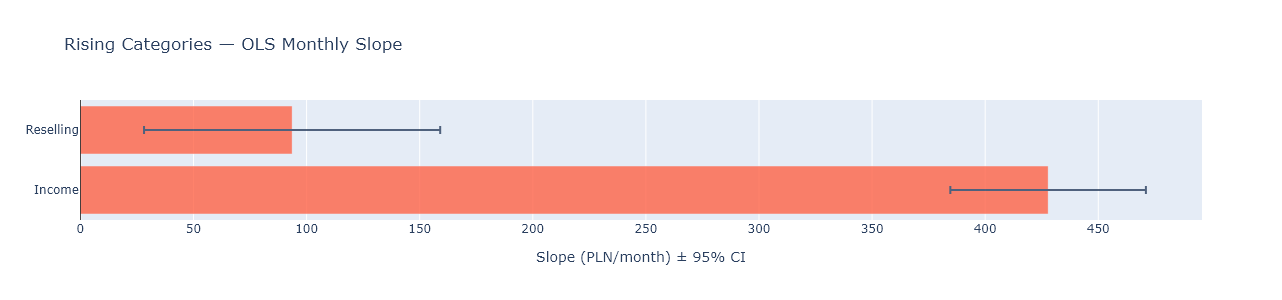


2 category(ies) flagged as rising.


In [5]:
rising_cats = trend_summary[trend_summary["trend_class"] == "rising"].copy()

if rising_cats.empty:
    print("No rising categories detected.")
else:
    slopes = rising_cats["trend_slope"].values
    ci_lower = rising_cats["trend_ci_lower"].values if "trend_ci_lower" in rising_cats else slopes
    ci_upper = rising_cats["trend_ci_upper"].values if "trend_ci_upper" in rising_cats else slopes
    error_x_minus = (slopes - ci_lower).tolist()
    error_x_plus = (ci_upper - slopes).tolist()

    fig_rising = go.Figure(go.Bar(
        x=slopes,
        y=rising_cats.index.tolist(),
        orientation="h",
        error_x=dict(type="data", symmetric=False,
                     array=error_x_plus,
                     arrayminus=error_x_minus),
        marker_color="tomato",
        opacity=0.8,
    ))
    fig_rising.add_vline(x=0, line_color="black", line_width=0.8)
    fig_rising.update_layout(
        title="Rising Categories — OLS Monthly Slope",
        xaxis_title="Slope (PLN/month) ± 95% CI",
        height=max(300, len(rising_cats) * 50),
    )
    fig_rising.show()
    print(f"\n{len(rising_cats)} category(ies) flagged as rising.")


## Step 5 — Monthly spend time series per category

Facet grid showing actual monthly spend and OLS trend line per category.
Seasonal categories are highlighted.

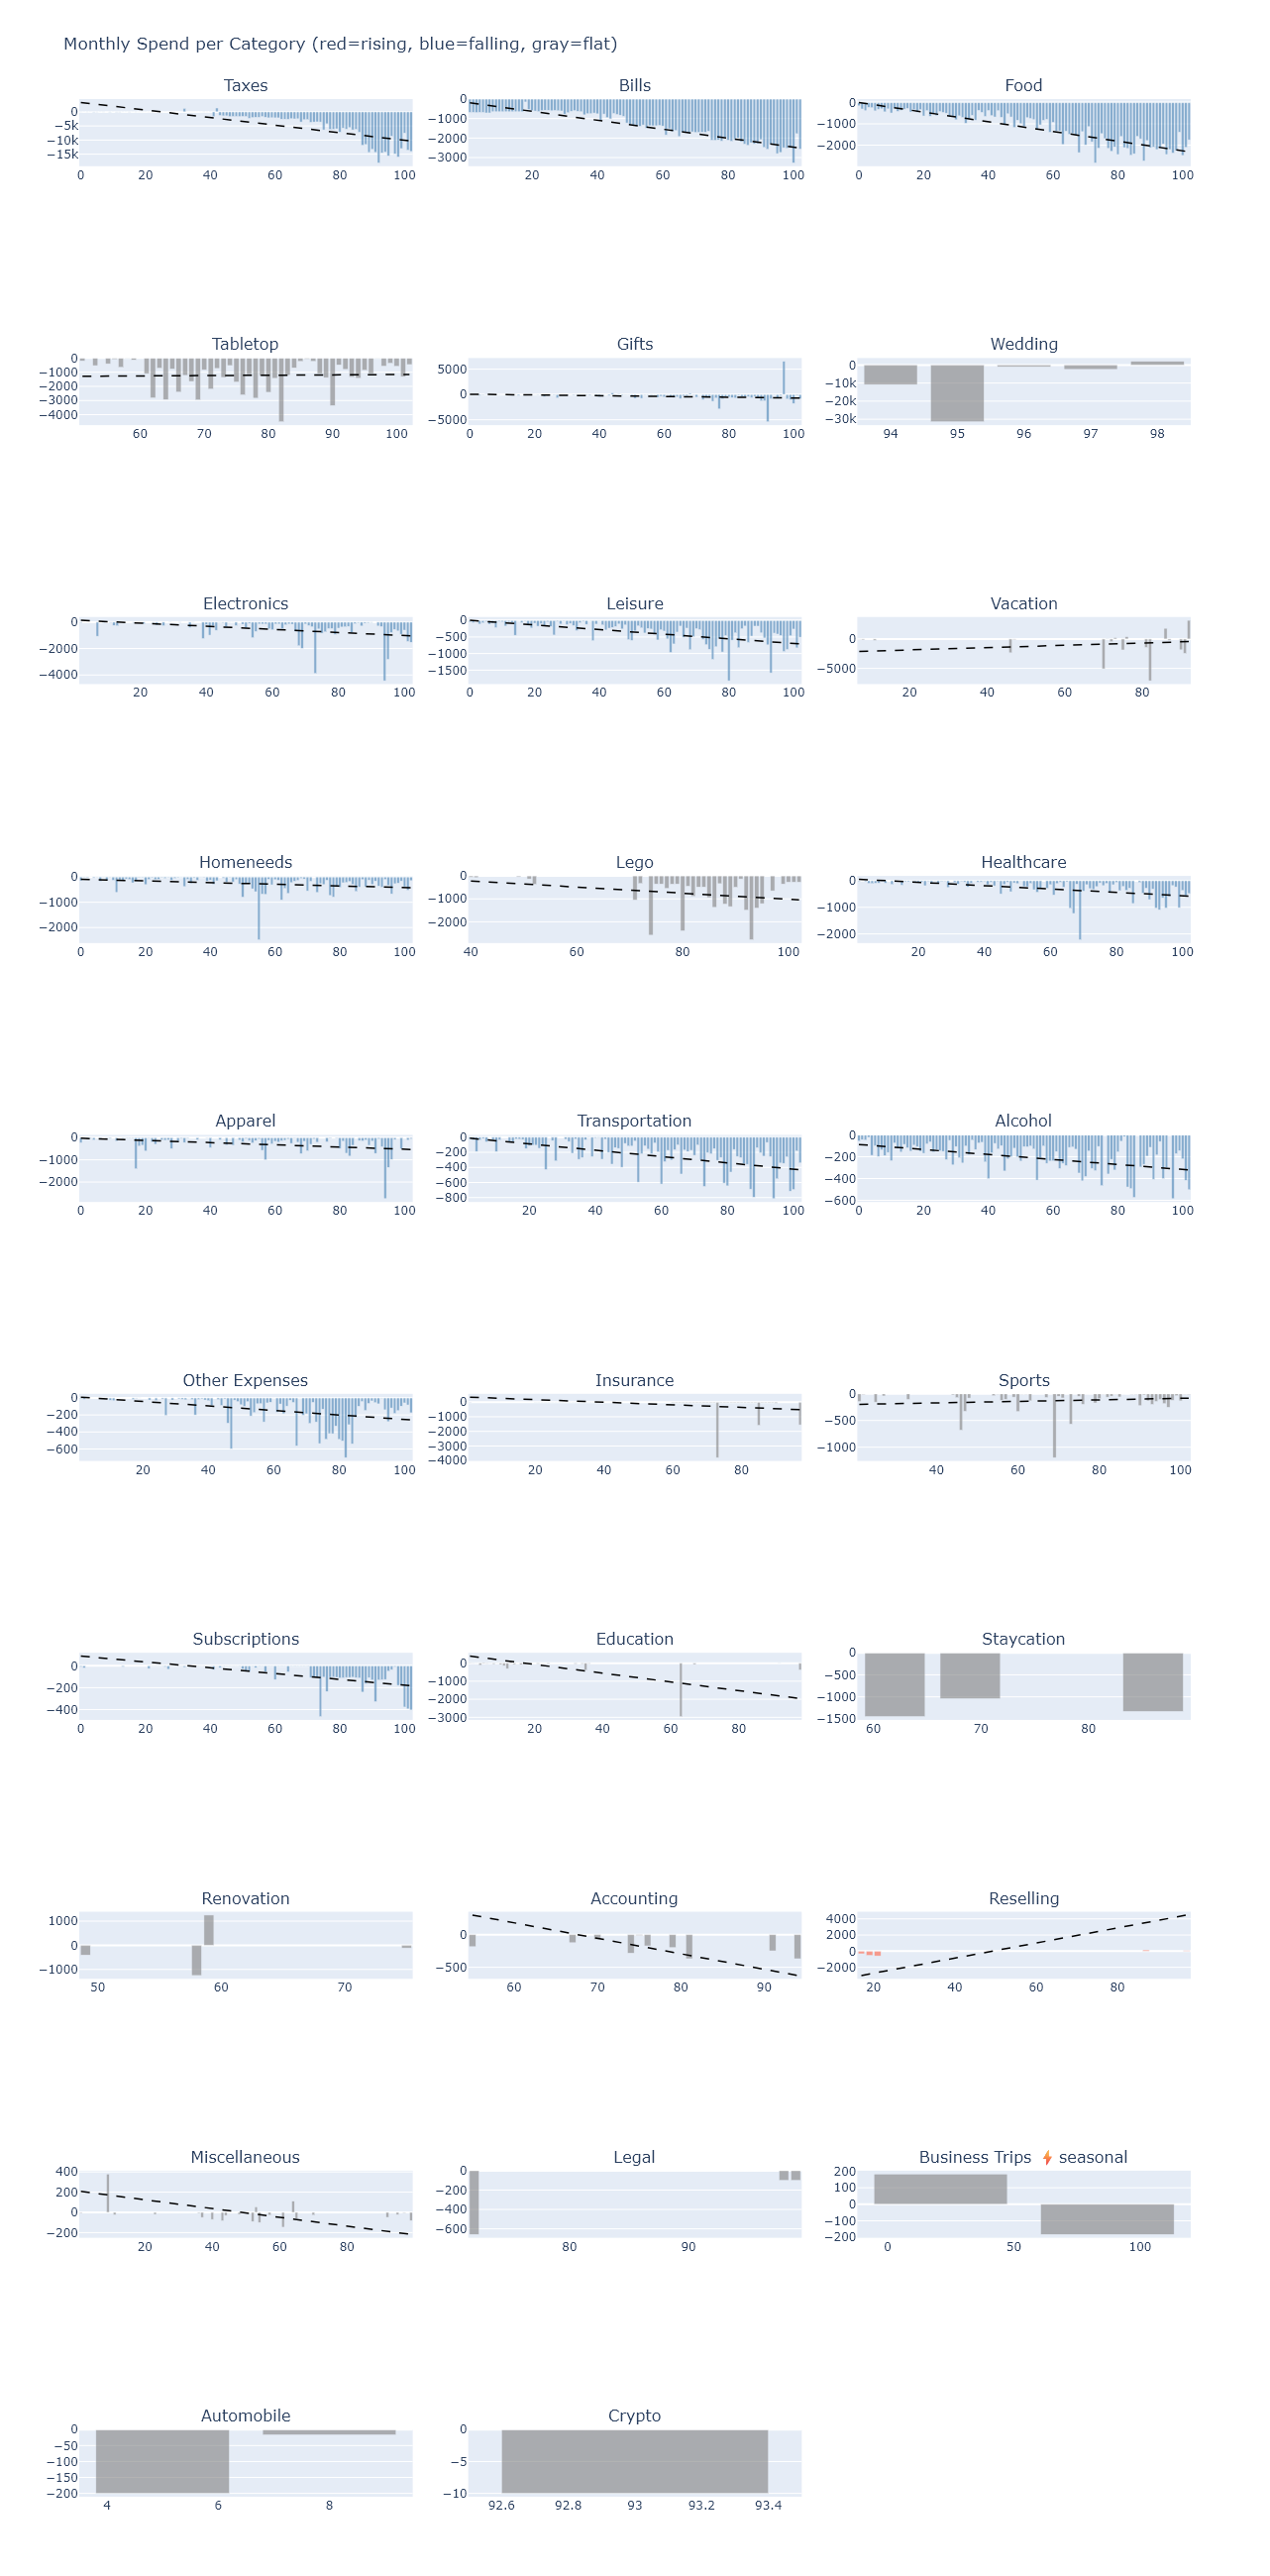

In [6]:
# Exclude Transfer and Income categories from the spend facets
expense_cats = (
    trend_summary[~trend_summary.index.isin(["Transfer", "Income"])]
    .sort_values("share_pct", ascending=False)
    .index.tolist()
)

n_cats = len(expense_cats)
ncols = 3
nrows = (n_cats + ncols - 1) // ncols

# Build subplot titles (pad to fill the grid)
subplot_titles = expense_cats + [""] * (nrows * ncols - n_cats)

fig_facets = make_subplots(
    rows=nrows, cols=ncols,
    subplot_titles=subplot_titles,
    shared_xaxes=False,
    vertical_spacing=0.08,
    horizontal_spacing=0.05,
)

for i, cat in enumerate(expense_cats):
    row = i // ncols + 1
    col = i % ncols + 1
    cat_data = df_trends[df_trends["category"] == cat].sort_values("month_ordinal")
    x = cat_data["month_ordinal"].values
    y = cat_data["total_amount"].values

    is_seasonal = trend_summary.loc[cat, "is_seasonal"]
    trend_cls = trend_summary.loc[cat, "trend_class"]
    color = "tomato" if trend_cls == "rising" else ("steelblue" if trend_cls == "falling" else "gray")

    if is_seasonal:
        fig_facets.layout.annotations[i].text = cat + " ⚡seasonal"

    fig_facets.add_trace(
        go.Bar(x=x, y=y, marker_color=color, opacity=0.6, showlegend=False),
        row=row, col=col,
    )

    if trend_cls not in ("insufficient_data",):
        slope = trend_summary.loc[cat, "trend_slope"]
        intercept_raw = y.mean() - slope * x.mean()
        fig_facets.add_trace(
            go.Scatter(x=x, y=intercept_raw + slope * x,
                       mode="lines", line=dict(color="black", width=1.5, dash="dash"),
                       showlegend=False),
            row=row, col=col,
        )

fig_facets.update_layout(
    height=nrows * 260,
    title_text="Monthly Spend per Category (red=rising, blue=falling, gray=flat)",
)
fig_facets.show()


## Step 6 — Seasonal categories summary

Categories with CV > 0.4 across month-of-year means.
OLS trends for these categories are unreliable — use STL or manual review.

In [7]:
seasonal_cats = (
    df_trends.drop_duplicates("category")
    .set_index("category")
    .query("is_seasonal == True")[["seasonality_cv", "trend_class", "share_pct"]]
)

print(f"Seasonal categories (CV > 0.4): {len(seasonal_cats)}")
if not seasonal_cats.empty:
    display(seasonal_cats.rename(columns={"seasonality_cv": "cv"})
            .style.background_gradient(subset=["cv"], cmap="Oranges")
            .format({"cv": "{:.3f}", "share_pct": "{:.1f}%"}))

Seasonal categories (CV > 0.4): 1


,cv,trend_class,share_pct
category,,,
Business Trips,836.910,insufficient_data,0.0%


## Step 7 — Consecutive MoM rises

Categories that had ≥ 2 consecutive months of >20% month-over-month increases.

In [8]:
spiky = trend_summary[trend_summary["has_consecutive_rise"]].copy()
print(f"Categories with consecutive MoM rises (≥2 months, >20%): {len(spiky)}")
if not spiky.empty:
    display(spiky[["n_rise_runs", "trend_class", "share_pct"]].style.format({
        "share_pct": "{:.1f}%"
    }))

Categories with consecutive MoM rises (≥2 months, >20%): 21


,n_rise_runs,trend_class,share_pct
category,,,
Income,1,rising,59.0%
Taxes,1,falling,13.9%
Food,5,falling,4.5%
Tabletop,6,flat,2.3%
Gifts,7,falling,1.8%
Electronics,5,falling,1.6%
Leisure,11,falling,1.4%
Vacation,2,flat,1.1%
Homeneeds,10,falling,1.0%


## Step 8 — Save `expense_trends.parquet`

Only save if the trends look reasonable. Stop here if something looks wrong.

In [9]:
writer.save_interim(df_trends, "expense_trends")
print("Saved: data/interim/expense_trends.parquet")

2026-03-30 13:06:11 | src.storage.local_writer       | INFO     | Wrote 1639 rows to C:\Users\mkkom\MMEXtend\data\interim\expense_trends.parquet


Saved: data/interim/expense_trends.parquet
